Let's put my idea to test

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.random import default_rng
from scipy.optimize import minimize_scalar
import matplotlib.cm as cm
import itertools
from itertools import combinations
from joblib import Parallel, delayed
import pickle
from mpl_toolkits.mplot3d import Axes3D
from scipy.optimize import root_scalar
from scipy.sparse.linalg import eigsh
from scipy.sparse import csr_matrix, lil_matrix
from collections import defaultdict
from scipy.sparse.linalg import expm_multiply
from scipy.linalg import svd
from scipy.optimize import curve_fit
from scipy.optimize import brentq
from scipy.linalg import logm, sqrtm, expm
from qutip import *

In [2]:
# -----------------------------------------------------------
#    DEFINING VARIOUS OBSERVABLES
# -----------------------------------------------------------

# 1) Partial trace, trace distance, fidelity, relative entropy between two density matrices

def reduced_density_matrix_general_bosonic(rho, basis, keep_sites):
    """
    Partial trace over all sites except keep_sites for bosonic occupation tuple basis.
    """
    dim_red = 2 ** len(keep_sites)  # assumes local dim = 2 (i.e., truncation)
    state_map = {}
    groups = defaultdict(list)

    def occ_to_index(occ):
        return sum((bit << (len(keep_sites) - 1 - i)) for i, bit in enumerate(occ))

    for idx, state in enumerate(basis):
        keep_occ = tuple(state[s] for s in keep_sites)
        rest_occ = tuple(state[i] for i in range(len(state)) if i not in keep_sites)
        keep_idx = occ_to_index(keep_occ)
        state_map[idx] = (rest_occ, keep_idx)
        groups[rest_occ].append(idx)

    rho_red = np.zeros((dim_red, dim_red), dtype=complex)
    for rest_val, indices in groups.items():
        for i in indices:
            rest_i, red_i = state_map[i]
            for j in indices:
                rest_j, red_j = state_map[j]
                rho_red[red_i, red_j] += rho[i, j]

    return rho_red

    # I'm trusting this works

def fidelity(rho1, rho2):
    sqrt_rho1 = sqrtm(rho1)
    return np.real(np.trace(sqrtm(sqrt_rho1 @ rho2 @ sqrt_rho1))**2)

def relative_entropy(rho1, rho2):
    return np.trace(rho1 @ (logm(rho1) - logm(rho2))).real

def trace_distance_calc(rho1, rho2):
    diff = rho1 - rho2
    s = svd(diff, compute_uv=False)
    return 0.5 * np.sum(np.abs(s))

# --------------------------------------------------------------
#     OTHER PERTINENT FUNCTIONS
# --------------------------------------------------------------

def generate_bosonic_basis(L, num_particles=2, max_occupancy=2):
    """Generates all bosonic Fock states with num_particles across L sites."""
    if max_occupancy is None:
        max_occupancy = num_particles

    def compositions(n, k):
        if k == 1:
            yield (n,)
        else:
            for i in range(min(n, max_occupancy) + 1):
                for tail in compositions(n - i, k - 1):
                    yield (i,) + tail

    return list(compositions(num_particles, L))

def b_dag(i, state):
    """Bosonic creation operator at site i."""
    if state[i] >= len(state):  # unbounded occupation could be dangerous
        return 0, None
    new_state = list(state)
    new_state[i] += 1
    amp = np.sqrt(state[i] + 1)
    return amp, tuple(new_state)

def b(i, state):
    """Bosonic annihilation operator at site i."""
    if state[i] == 0:
        return 0, None
    new_state = list(state)
    new_state[i] -= 1
    amp = np.sqrt(state[i])
    return amp, tuple(new_state)

def create_bosonic_hamiltonian_n_particles(L, t=3.5, U=1, t_nnn=1, U_nnn=0.1, num_particles=2, max_occupancy=None):
    basis = generate_bosonic_basis(L, num_particles=num_particles, max_occupancy=max_occupancy)
    dim = len(basis)
    index_map = {state: i for i, state in enumerate(basis)}
    H = np.zeros((dim, dim), dtype=complex)

    for state in basis:
        i0 = index_map[state]

        # Nearest neighbor hopping and interaction
        for i in range(L - 1):
            j = i + 1
            amp1, state1 = b(j, state)
            if amp1 != 0:
                amp2, state2 = b_dag(i, state1)
                if amp2 != 0 and state2 in index_map:
                    i1 = index_map[state2]
                    H[i1, i0] += -t * amp1 * amp2

            amp1, state1 = b(i, state)
            if amp1 != 0:
                amp2, state2 = b_dag(j, state1)
                if amp2 != 0 and state2 in index_map:
                    i1 = index_map[state2]
                    H[i1, i0] += -t * amp1 * amp2

            H[i0, i0] += U * state[i] * state[j]

        # Next-nearest neighbor hopping and interaction
        for i in range(L - 2):
            k = i + 2
            amp1, state1 = b(k, state)
            if amp1 != 0:
                amp2, state2 = b_dag(i, state1)
                if amp2 != 0 and state2 in index_map:
                    i1 = index_map[state2]
                    H[i1, i0] += -t_nnn * amp1 * amp2

            amp1, state1 = b(i, state)
            if amp1 != 0:
                amp2, state2 = b_dag(k, state1)
                if amp2 != 0 and state2 in index_map:
                    i1 = index_map[state2]
                    H[i1, i0] += -t_nnn * amp1 * amp2

            H[i0, i0] += U_nnn * state[i] * state[k]
    return H, basis

def simulate_long_time_n_particles_bosonic(L=6, t_max=10.0, steps=10, H=None, basis=None, evals=None, evecs=None, num_particles=3, max_occupancy=None):

    times = np.linspace(0, t_max, steps)

    if H is None or basis is None:
        H, basis = create_bosonic_hamiltonian_n_particles(L, num_particles=num_particles, max_occupancy=max_occupancy)
        print("Computed H and basis")
    else:
        print("Using a precomputed H and basis to avoid redundant computation")

    if evals is None or evecs is None:
        evals, evecs = np.linalg.eigh(H)
        print("Computed evals and evecs")
    else:
        print("Precomputed eigenvalues and eigenvectors are being used.")

    dim = len(basis)
    psi0 = np.zeros(dim, dtype=complex)
    psi0[0] = 1.0  # Start in first basis state
    proj_psi0 = evecs.T.conj() @ psi0

    occupations_no_error = np.zeros((steps, L))

    for idx, t in enumerate(times):
        psi_t = evecs @ (np.exp(-1j * evals * t) * proj_psi0)
        probs = np.abs(psi_t)**2
        for site in range(L):
            for j, state in enumerate(basis):
                occupations_no_error[idx, site] += probs[j] * state[site]

    return times, occupations_no_error, psi_t, H, basis, evals, evecs

def thermal_expectation_Hamiltonian_bosonic(beta, evals):
    """
    Thermal expectation ⟨H⟩_β = Tr[H e^{-βH}]/Z, safe against overflow for bosons.
    """
    e_min = np.min(beta * evals)  # For numerical stability
    weights = np.exp(-(beta * evals - e_min))
    Z = np.sum(weights)
    thermal_E = np.sum(evals * weights) / Z
    return thermal_E

def find_beta_with_neg_temps_bosonic(H, psi0, bracket=(-500, 500), plot=False):

    E = np.vdot(psi0, H @ psi0).real
    evals, _ = np.linalg.eigh(H)

    def f(beta):
        return thermal_expectation_Hamiltonian_bosonic(beta, evals) - E

    f_lo = f(bracket[0])
    f_hi = f(bracket[1])

    if np.sign(f_lo) == np.sign(f_hi):
        if plot:
            import matplotlib.pyplot as plt
            beta_vals = np.linspace(bracket[0], bracket[1], 500)
            thermal_vals = [thermal_expectation_Hamiltonian_bosonic(b, evals) for b in beta_vals]
            plt.plot(beta_vals, thermal_vals, label="⟨H⟩_thermal(β)")
            plt.axhline(E, color='r', linestyle='--', label="E_init")
            plt.xlabel("β")
            plt.ylabel("Energy")
            plt.legend()
            plt.title("No root found: energy outside thermal range")
            plt.show()
        raise RuntimeError("No root in bracket: energy outside accessible thermal range.")

    beta_star = brentq(f, *bracket, xtol=1e-10)
    print(f"beta_star = {beta_star}")
    return beta_star, E

def reduced_density_matrix_general_bosonic(rho, basis, keep_sites):

    # Map from full state to reduced occupation and traced-out occupation
    state_map = {}
    groups = defaultdict(list)

    # First pass: build grouping by "traced-out" sites
    for idx, state in enumerate(basis):
        keep_occ = tuple(state[s] for s in keep_sites)
        trace_occ = tuple(state[s] for s in range(len(state)) if s not in keep_sites)
        state_map[idx] = (trace_occ, keep_occ)
        groups[trace_occ].append(idx)

    # Build index mapping for reduced basis
    keep_occ_set = sorted(set(keep for _, keep in state_map.values()))
    keep_occ_to_index = {keep: i for i, keep in enumerate(keep_occ_set)}
    dim_red = len(keep_occ_set)

    rho_red = np.zeros((dim_red, dim_red), dtype=complex)

    for trace_val, indices in groups.items():
        for i in indices:
            _, keep_i = state_map[i]
            red_i = keep_occ_to_index[keep_i]
            for j in indices:
                _, keep_j = state_map[j]
                red_j = keep_occ_to_index[keep_j]
                rho_red[red_i, red_j] += rho[i, j]

    return rho_red

def run_plain_point_bosonic(t_max, evecs, evals, proj_psi0, basis, red_rho_thermal, keep_sites):
    psi_t = evecs @ (np.exp(-1j * evals * t_max) * proj_psi0)
    rho_t = np.outer(psi_t, psi_t.conj())
    red_rho_t = reduced_density_matrix_general_bosonic(rho_t, basis, keep_sites)
    print("Reduced density matrix computed")

    D = trace_distance_calc(red_rho_t, red_rho_thermal)
    F = fidelity(red_rho_t, red_rho_thermal)
    S = relative_entropy(red_rho_t, red_rho_thermal)

    print(f"t_max = {t_max:.2f}")
    print(f"  Trace distance D(rho_t, rho_thermal) = {D:.6f}")
    print(f"  Infidelity = {1-F:.6f}")
    print(f"  Relative entropy = {S:.6f}")

    return D, 1-F, S

# --------------------------------------------------------------
#     CAVITY-COUPLED EXCITONS FUNCTION
# --------------------------------------------------------------

def generate_exciton_cavity_basis(L, num_particles, N_cav=5):
    """
    Generate basis states for:
    - One cavity mode (boson): occupancy 0..N_cav
    - L excitons (two-level): occupancy 0 or 1 each
    conserving total excitation number = num_particles.

    Returns:
        basis: list of tuples (n_cav, n_1, n_2, ..., n_L)
    """
    basis = []
    for n_cav in range(N_cav + 1):
        remaining = num_particles - n_cav
        if remaining < 0 or remaining > L:
            continue
        # Choose which excitons are excited
        for excitons in itertools.combinations(range(L), remaining):
            state = [0] * L
            for i in excitons:
                state[i] = 1
            basis.append((n_cav, *state))
    return basis

def create_exciton_cavity_hamiltonian(L, t=3, U=1, t_nnn=0.5, U_nnn=0.1,
                                      g=0.2, omega_c=0.5, num_particles=2, N_cav=4):
    """
    Create Hamiltonian for a chain of L two-level excitons + 1 cavity mode.

    - Basis: (n_cav, n_ex1, n_ex2, ..., n_exL)
    - Excitons: two-level systems (0 or 1)
    - Cavity: bosonic (0..N_cav)
    - Cavity couples to the *first exciton* (index 1) with coupling g.
    """
    basis = generate_exciton_cavity_basis(L, num_particles=num_particles, N_cav=N_cav)
    dim = len(basis)
    index_map = {state: i for i, state in enumerate(basis)}
    H = np.zeros((dim, dim), dtype=complex)

    for state in basis:
        i0 = index_map[state]

        # --- Exciton chain hopping + interaction ---
        for i in range(1, L):  # exciton indices: 1 ... L
            j = i + 1

            if j > L:
                continue

            # Hopping: -t (b_i† b_j + h.c.)
            amp1, state1 = b(j, state)
            if amp1 != 0:
                amp2, state2 = b_dag(i, state1)
                if amp2 != 0 and state2 in index_map:
                    H[index_map[state2], i0] += -t * amp1 * amp2

            amp1, state1 = b(i, state)
            if amp1 != 0:
                amp2, state2 = b_dag(j, state1)
                if amp2 != 0 and state2 in index_map:
                    H[index_map[state2], i0] += -t * amp1 * amp2

            # Interaction: U n_i n_j
            H[i0, i0] += U * state[i] * state[j]

        # --- Next-nearest-neighbor hopping + interaction ---
        for i in range(1, L - 1):
            k = i + 2
            if k > L:
                continue

            # Hopping: -t_nnn (b_i† b_k + h.c.)
            amp1, state1 = b(k, state)
            if amp1 != 0:
                amp2, state2 = b_dag(i, state1)
                if amp2 != 0 and state2 in index_map:
                    H[index_map[state2], i0] += -t_nnn * amp1 * amp2

            amp1, state1 = b(i, state)
            if amp1 != 0:
                amp2, state2 = b_dag(k, state1)
                if amp2 != 0 and state2 in index_map:
                    H[index_map[state2], i0] += -t_nnn * amp1 * amp2

            # Interaction: U_nnn n_i n_k
            H[i0, i0] += U_nnn * state[i] * state[k]

        # --- Cavity energy term ---
        n_cav = state[0]  # first entry = cavity occupancy
        H[i0, i0] += omega_c * n_cav

        # --- Cavity–first exciton coupling: g (a† b_1 + a b_1†) ---
        j = 1  # exciton index now 1 (since 0 = cavity)
        # a† b_1
        amp1, state1 = b(j, state)
        if amp1 != 0:
            amp2, state2 = b_dag(0, state1)
            if amp2 != 0 and state2 in index_map:
                H[index_map[state2], i0] += g * amp1 * amp2
        # a b_1†
        amp1, state1 = b_dag(j, state)
        if amp1 != 0:
            amp2, state2 = b(0, state1)
            if amp2 != 0 and state2 in index_map:
                H[index_map[state2], i0] += g * amp1 * amp2

    return H, basis


def reduced_density_matrix_with_cavity(rho, basis, keep_exciton_sites):
    """
    rho: full density matrix in the full basis
    basis: list of tuples (n_cav, n_ex1, n_ex2, ..., n_exL)
    keep_exciton_sites: list of exciton site indices in [0..L-1] to keep (these index the exciton chain,
                        NOT the basis tuple)
    Returns reduced density matrix on the kept exciton sites (ordered as keep_exciton_sites).
    """
    # map full-state index -> (trace_occ, keep_occ)
    state_map = {}
    groups = defaultdict(list)

    L_plus1 = len(basis[0])  # should be L + 1
    L = L_plus1 - 1

    for idx, state in enumerate(basis):
        # state is (n_cav, n_ex1, ..., n_exL)
        # keep_occ should collect exciton occupations for the requested exciton indices
        keep_occ = tuple(state[1 + s] for s in keep_exciton_sites)  # shift by 1 to skip cavity
        # trace_occ should include cavity + all excitons NOT in keep_exciton_sites
        trace_list = [state[0]]  # cavity first
        for s in range(L):
            if s not in keep_exciton_sites:
                trace_list.append(state[1 + s])
        trace_occ = tuple(trace_list)
        state_map[idx] = (trace_occ, keep_occ)
        groups[trace_occ].append(idx)

    # Build reduced basis ordering for kept excitons
    keep_occ_set = sorted({keep for _, keep in state_map.values()})
    keep_occ_to_index = {keep: i for i, keep in enumerate(keep_occ_set)}
    dim_red = len(keep_occ_set)
    rho_red = np.zeros((dim_red, dim_red), dtype=complex)

    # Sum over traced-out sectors
    for trace_val, indices in groups.items():
        for i in indices:
            _, keep_i = state_map[i]
            red_i = keep_occ_to_index[keep_i]
            for j in indices:
                _, keep_j = state_map[j]
                red_j = keep_occ_to_index[keep_j]
                rho_red[red_i, red_j] += rho[i, j]

    return rho_red



beta_star = 0.0022937519674189936


/home/sameer/anaconda3/envs/quantum_algorithms/lib/python3.12/site-packages/scipy/linalg/_matfuncs.py:202: LogmNearlySingularWarning: The logm input matrix may be nearly singular.
  F = scipy.linalg._matfuncs_inv_ssq._logm(A)
/home/sameer/anaconda3/envs/quantum_algorithms/lib/python3.12/site-packages/scipy/linalg/_matfuncs.py:202: LogmNearlySingularWarning: The logm input matrix may be nearly singular.
  F = scipy.linalg._matfuncs_inv_ssq._logm(A)
/home/sameer/anaconda3/envs/quantum_algorithms/lib/python3.12/site-packages/scipy/linalg/_matfuncs.py:202: LogmNearlySingularWarning: The logm input matrix may be nearly singular.
  F = scipy.linalg._matfuncs_inv_ssq._logm(A)
/home/sameer/anaconda3/envs/quantum_algorithms/lib/python3.12/site-packages/scipy/linalg/_matfuncs.py:202: LogmNearlySingularWarning: The logm input matrix may be nearly singular.
  F = scipy.linalg._matfuncs_inv_ssq._logm(A)
/home/sameer/anaconda3/envs/quantum_algorithms/lib/python3.12/site-packages/scipy/linalg/_matfun

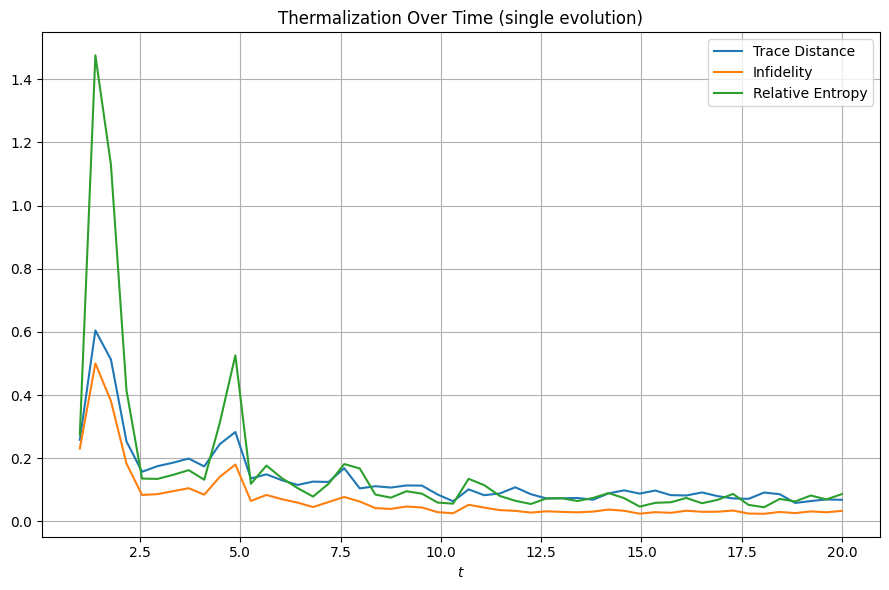

In [5]:
# --- Setup ---
L = 24
keep_sites = [L//2 + i for i in range(-1, 2)]
t_max = 20
num_samples = 50
times = np.linspace(1, t_max, num_samples)

# --- Hamiltonian and initial state ---
H, basis = create_bosonic_hamiltonian_n_particles(L=L, num_particles=3)
evals, evecs = np.linalg.eigh(H)
psi0 = np.zeros(len(basis), dtype=complex)
psi0[0] = 1.0
proj_psi0 = evecs.T.conj() @ psi0

# --- Thermal state and reduced version ---
beta_star, _ = find_beta_with_neg_temps_bosonic(H, psi0, bracket=(-100, 100))
weights = np.exp(-beta_star * evals)
weights /= np.sum(weights)
rho_thermal_full = (evecs * weights[np.newaxis, :]) @ evecs.conj().T
red_rho_thermal = reduced_density_matrix_general_bosonic(rho_thermal_full, basis, keep_sites)

# --- Function to compute observables at a single time ---
def compute_observables(t):
    psi_t = evecs @ (np.exp(-1j * evals * t) * proj_psi0)
    rho_t = np.outer(psi_t, psi_t.conj())
    red_rho_t = reduced_density_matrix_general_bosonic(rho_t, basis, keep_sites)

    D = trace_distance_calc(red_rho_t, red_rho_thermal)
    F = fidelity(red_rho_t, red_rho_thermal)
    S = relative_entropy(red_rho_t, red_rho_thermal)
    return D, 1 - F, S

# --- Parallel execution ---
results = Parallel(n_jobs=-1)(delayed(compute_observables)(t) for t in times)

# --- Unpack results ---
trace_distances_plain, infidelities_plain, rel_entropies_plain = map(list, zip(*results))

# --- Plotting ---
plt.figure(figsize=(9, 6))
plt.plot(times, trace_distances_plain, label='Trace Distance')
plt.plot(times, infidelities_plain, label='Infidelity')
plt.plot(times, rel_entropies_plain, label='Relative Entropy')
plt.xlabel(r'$t$')
plt.title('Thermalization Over Time (single evolution)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 13.1s

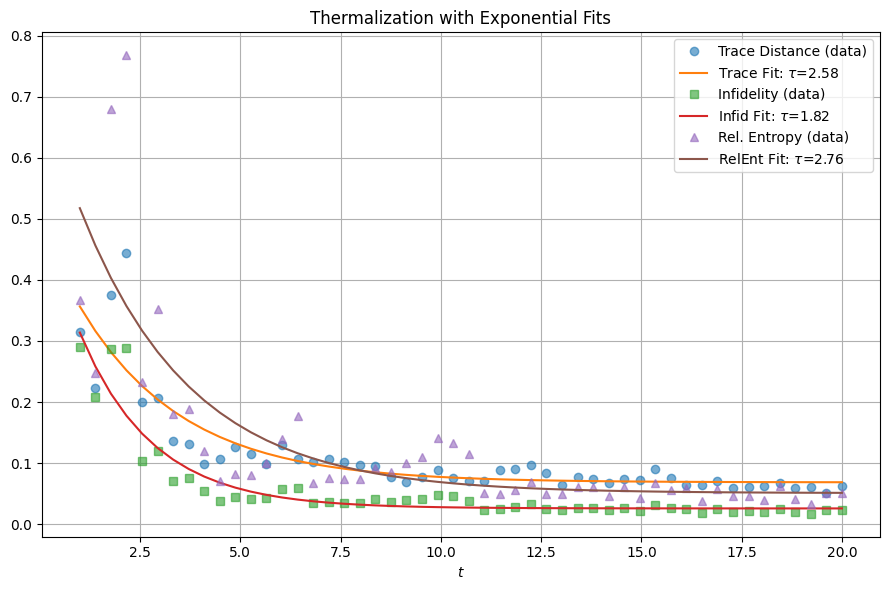

In [19]:
def decay_model(t, A, tau, B):
    return A * np.exp(-t / tau) + B

# Fit each quantity
popt_trace, _ = curve_fit(decay_model, times, trace_distances_plain, p0=(1, 5, 0))
popt_infid, _ = curve_fit(decay_model, times, infidelities_plain, p0=(1, 5, 0))
popt_relent, _ = curve_fit(decay_model, times, rel_entropies_plain, p0=(1, 5, 0))

# Generate fit curves
fit_trace = decay_model(times, *popt_trace)
fit_infid = decay_model(times, *popt_infid)
fit_relent = decay_model(times, *popt_relent)

# Plot with fits
plt.figure(figsize=(9, 6))
plt.plot(times, trace_distances_plain, 'o', label='Trace Distance (data)', alpha=0.6)
plt.plot(times, fit_trace, '-', label=f'Trace Fit: $\\tau$={popt_trace[1]:.2f}')

plt.plot(times, infidelities_plain, 's', label='Infidelity (data)', alpha=0.6)
plt.plot(times, fit_infid, '-', label=f'Infid Fit: $\\tau$={popt_infid[1]:.2f}')

plt.plot(times, rel_entropies_plain, '^', label='Rel. Entropy (data)', alpha=0.6)
plt.plot(times, fit_relent, '-', label=f'RelEnt Fit: $\\tau$={popt_relent[1]:.2f}')

plt.xlabel(r'$t$')
plt.title('Thermalization with Exponential Fits')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Building the cavity onto this

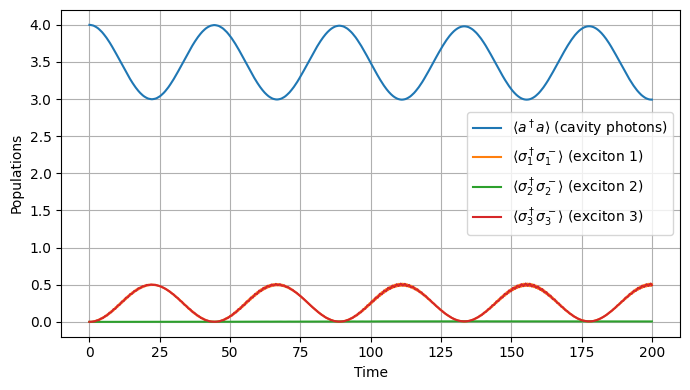

In [ ]:
# One cavity with 3 photons exchanging excitations with 3 excitons.

# ----- Parameters -----
wc = 1.0       # cavity frequency
wx = 1.0       # exciton frequency (resonant with cavity)
g  = 0.05      # cavity-exciton coupling strength
J = 3
N_cav = 12      # cavity Hilbert space truncation (enough for 3 photons)
N_exc = 3      # number of excitons

# ----- Operators -----
# Cavity annihilation operator
a = tensor(destroy(N_cav), qeye(2), qeye(2), qeye(2))

# Exciton lowering operators
sm1 = tensor(qeye(N_cav), destroy(2), qeye(2), qeye(2))
sm2 = tensor(qeye(N_cav), qeye(2), destroy(2), qeye(2))
sm3 = tensor(qeye(N_cav), qeye(2), qeye(2), destroy(2))
sm_ops = [sm1, sm2, sm3]
# sm_ops = [sm1, sm2]
# sm_ops = [sm1]

# ----- Hamiltonian -----
# Free energies
H_cav = wc * a.dag() * a
H_exc = wx * sum([sm.dag() * sm for sm in sm_ops])

# Uniform cavity-exciton coupling
# H_int = g * sum([a.dag() * sm + a * sm.dag() for sm in sm_ops]) + J * (sm1.dag() * sm2 + sm2.dag() * sm2)
H_int = g * (a.dag() * sm1 + a * sm1.dag()) - J * (sm1.dag() * sm2 + sm2.dag() * sm1 + sm2.dag() * sm3 + sm3.dag() * sm2)

# Total Hamiltonian (no exciton–exciton terms)
H = H_cav + H_exc + H_int

# ----- Initial state -----
# Cavity has 3 photons, all excitons in ground state |ggg⟩
psi0 = tensor(basis(N_cav, 4), basis(2, 0), basis(2, 0), basis(2, 0))

# ----- Time evolution -----
tlist = np.linspace(0, 200, 4000)
result = mesolve(H, psi0, tlist, [], [a.dag() * a, sm1.dag() * sm1, sm2.dag() * sm2, sm3.dag() * sm3])

# ----- Expectation values -----
n_cav = result.expect[0]
ex_1 = result.expect[1]
ex_2 = result.expect[2]
ex_3 = result.expect[3]

# ----- Plot -----
plt.figure(figsize=(7, 4))
plt.plot(tlist, n_cav, label=r'$\langle a^\dagger a \rangle$ (cavity photons)')
plt.plot(tlist, ex_1, label=r'$\langle \sigma_1^\dagger \sigma_1^- \rangle$ (exciton 1)')
plt.plot(tlist, ex_2, label=r'$\langle \sigma_2^\dagger \sigma_2^- \rangle$ (exciton 2)')
plt.plot(tlist, ex_3, label=r'$\langle \sigma_3^\dagger \sigma_3^- \rangle$ (exciton 3)')
plt.xlabel('Time')
plt.ylabel('Populations')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# CONCLUSIONS:

# At J>>g,
# 1) Cavity gets effectively coupled to ex1, ex3 (like in J=0 case with g coupling to ex1, ex3)
# 2) p1, p3 oscillate at the rate g (NOT J) which reinforces 1)
# 3) There are small oscillations in ex1, ex3, most likely at the rate J.
# 4) As J increases, smaller oscillations become faster and hence the overall curve smoothens out. Overall curve maintains the rate of its oscillation.
#  So...large hopping strengths between the excitons leads to effective couplings of the exciton with the cavity.

# Connection to our thermalization model:
# So thermalization dynamics would probably be refelcted in those smaller oscillations, and the bigger oscillations reflect the cavity-exciton coupling strength.
# Therefore, this sets the scale for g/J that Ajay can use to probe thermalization.

/home/sameer/anaconda3/envs/quantum_algorithms/lib/python3.12/site-packages/qutip/solver/solver_base.py:576: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


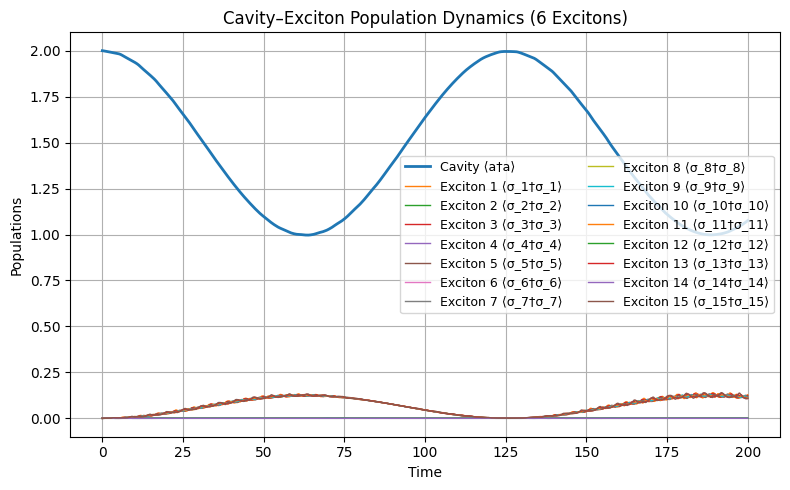

In [ ]:
# Now expanding to more number of excitons with nearest-neighbour hopping. Cavity is coupled to the first exciton.

# ----- Parameters -----
wc = 1.0       # cavity frequency
wx = 1.0       # exciton frequency (resonant with cavity)
g  = 0.05      # cavity-exciton coupling strength
J  = 3       # exciton-exciton coupling
N_cav = 12     # cavity Hilbert space truncation
N_exc = 15      # number of excitons

# ----- Operators -----
# Build tensor structure dynamically
# Cavity operator acts only on the first Hilbert space
a = tensor([destroy(N_cav)] + [qeye(2) for _ in range(N_exc)])

# Build exciton lowering operators sm_i
sm_ops = []
for i in range(N_exc):
    op_list = [qeye(N_cav)] + [qeye(2) for _ in range(N_exc)]
    op_list[i + 1] = destroy(2)   # +1 because cavity is first subsystem
    sm_ops.append(tensor(op_list))

# ----- Hamiltonian -----
# Free energies
H_cav = wc * a.dag() * a
H_exc = wx * sum([sm.dag() * sm for sm in sm_ops])

# Coupling terms
# Cavity couples only to exciton 1
H_g = g * (a.dag() * sm_ops[0] + a * sm_ops[0].dag())

# Nearest-neighbor exciton couplings
H_J = 0
for i in range(N_exc - 1):
    H_J += -J * (sm_ops[i].dag() * sm_ops[i+1] + sm_ops[i+1].dag() * sm_ops[i])

# Total Hamiltonian
H = H_cav + H_exc + H_g + H_J

# ----- Initial state -----
# Cavity has 3 photons, all excitons in ground state |gggggg⟩
psi0 = tensor([basis(N_cav, 2)] + [basis(2, 0) for _ in range(N_exc)])

# ----- Time evolution -----
tlist = np.linspace(0, 200, 500)
obs = [a.dag() * a] + [sm.dag() * sm for sm in sm_ops]  # photon + exciton populations

result = mesolve(H, psi0, tlist, [], obs)

# ----- Expectation values -----
n_cav = result.expect[0]
exc_pops = result.expect[1:]  # exciton populations list

# ----- Plot -----
plt.figure(figsize=(8, 5))
plt.plot(tlist, n_cav, label='Cavity ⟨a†a⟩', lw=2)
for i, ex_pop in enumerate(exc_pops, start=1):
    plt.plot(tlist, ex_pop, label=fr'Exciton {i} ⟨σ_{i}†σ_{i}⟩', lw=1)
plt.xlabel('Time')
plt.ylabel('Populations')
plt.legend(ncol=2, fontsize=9)
plt.grid(True)
plt.title('Cavity–Exciton Population Dynamics (6 Excitons)')
plt.tight_layout()
plt.show()

# N_ex = 12, 52.7s
# N_ex = 15, 9m 50.1s

(IGNORE THIS) Trying to reduce computational load by moving away from QuTiP and using some Python code

In [ ]:
# IGNORE THIS

# --- Utilities ---
def popcount(x): 
    return bin(x).count("1")

def build_total_excitation_basis(N_cav_max, N_exc, Ntot):
    states = []
    sindex = {}
    idx = 0
    for n_cav in range(N_cav_max + 1):
        k_exc = Ntot - n_cav
        if not (0 <= k_exc <= N_exc):
            continue
        for occ in combinations(range(N_exc), k_exc):
            mask = sum(1 << i for i in occ)
            states.append((n_cav, mask))
            sindex[(n_cav, mask)] = idx
            idx += 1
    return states, sindex

def build_H_cavity_exciton(N_cav_max, N_exc, Ntot, wc, wx, g, J):
    states, sindex = build_total_excitation_basis(N_cav_max, N_exc, Ntot)
    dim = len(states)
    H = lil_matrix((dim, dim), dtype=np.complex128)

    for idx, (n_cav, mask) in enumerate(states):
        n_exc = popcount(mask)
        H[idx, idx] += wc * n_cav + wx * n_exc

        # Exciton hopping (σ_i^+ σ_{i+1}^- + h.c.)
        for i in range(N_exc - 1):
            has_i = (mask >> i) & 1
            has_ip1 = (mask >> (i + 1)) & 1
            if has_ip1 and not has_i:
                newmask = mask ^ (1 << i) ^ (1 << (i + 1))
                j = sindex.get((n_cav, newmask))
                if j is not None:
                    H[idx, j] += -J
                    H[j, idx] += -J

        # Cavity–exciton coupling g(a†σ_i^- + aσ_i^+)
        if n_cav < N_cav_max:
            for i in range(N_exc):
                if (mask >> i) & 1:
                    newmask = mask ^ (1 << i)
                    j = sindex.get((n_cav + 1, newmask))
                    if j is not None:
                        val = g * np.sqrt(n_cav + 1)
                        H[idx, j] += val
                        H[j, idx] += np.conj(val)
    return H.tocsr(), states, sindex

def cavity_pop_from_vector(psi_vec, states):
    probs = np.abs(psi_vec)**2
    return sum(p * n_cav for p, (n_cav, _) in zip(probs, states))

def exciton_pop_from_vector(psi_vec, states, site):
    probs = np.abs(psi_vec)**2
    return sum(p * ((mask >> site) & 1) for p, (_, mask) in zip(probs, states))

# --- Parameters ---
N_exc = 64
N_cav_max = 6     # must be >= 4
Ntot = 4          # total excitation number (4 photons initially)
wc, wx, g, J = 1.0, 1.0, 0.05, 1.0

# --- Build Hamiltonian ---
H_sparse, states, sindex = build_H_cavity_exciton(N_cav_max, N_exc, Ntot, wc, wx, g, J)
print("Hilbert space dimension:", H_sparse.shape[0])

# --- Initial state: |4 photons, all excitons in ground⟩ ---
n_cav0 = 4
mask0 = 0  # all excitons in ground state
idx0 = sindex[(n_cav0, mask0)]
psi0 = np.zeros(H_sparse.shape[0], dtype=complex)
psi0[idx0] = 1.0

# --- Time evolution ---
tlist = np.linspace(0, 200, 400)
psi = psi0.copy()
psis = []
for t0, t1 in zip(tlist[:-1], tlist[1:]):
    dt = t1 - t0
    psi = expm_multiply((-1j * H_sparse) * dt, psi)
    psis.append(psi.copy())

# --- Populations ---
pops_cav = [cavity_pop_from_vector(psi, states) for psi in psis]
pops_first = [exciton_pop_from_vector(psi, states, 0) for psi in psis]
pops_mid = [exciton_pop_from_vector(psi, states, N_exc // 2) for psi in psis]
pops_last = [exciton_pop_from_vector(psi, states, N_exc - 1) for psi in psis]

# --- Plot ---
plt.figure(figsize=(7, 5))
plt.plot(tlist[:-1], pops_cav, label="Cavity ⟨a†a⟩", lw=2)
plt.plot(tlist[:-1], pops_first, label="Exciton 1", lw=1.5)
plt.plot(tlist[:-1], pops_mid, label=f"Exciton {N_exc//2}", lw=1.5)
plt.plot(tlist[:-1], pops_last, label=f"Exciton {N_exc}", lw=1.5)
plt.xlabel("Time")
plt.ylabel("Population")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Hilbert space dimension: 679121


Going back to bosonic lattice code

Basis dimension (constrained by num_particles=2): 1226
Each basis tuple length (should be L+1 = 50): 50
idx for cav = 1225
beta_star = -0.002092734210624123
beta_star = -0.002092734210624123, E_init = 1.000000


/home/sameer/anaconda3/envs/quantum_algorithms/lib/python3.12/site-packages/scipy/linalg/_matfuncs.py:202: LogmNearlySingularWarning: The logm input matrix may be nearly singular.
  F = scipy.linalg._matfuncs_inv_ssq._logm(A)
/home/sameer/anaconda3/envs/quantum_algorithms/lib/python3.12/site-packages/scipy/linalg/_matfuncs.py:202: LogmNearlySingularWarning: The logm input matrix may be nearly singular.
  F = scipy.linalg._matfuncs_inv_ssq._logm(A)
/home/sameer/anaconda3/envs/quantum_algorithms/lib/python3.12/site-packages/scipy/linalg/_matfuncs.py:202: LogmNearlySingularWarning: The logm input matrix may be nearly singular.
  F = scipy.linalg._matfuncs_inv_ssq._logm(A)
/home/sameer/anaconda3/envs/quantum_algorithms/lib/python3.12/site-packages/scipy/linalg/_matfuncs.py:202: LogmNearlySingularWarning: The logm input matrix may be nearly singular.
  F = scipy.linalg._matfuncs_inv_ssq._logm(A)
/home/sameer/anaconda3/envs/quantum_algorithms/lib/python3.12/site-packages/scipy/linalg/_matfun

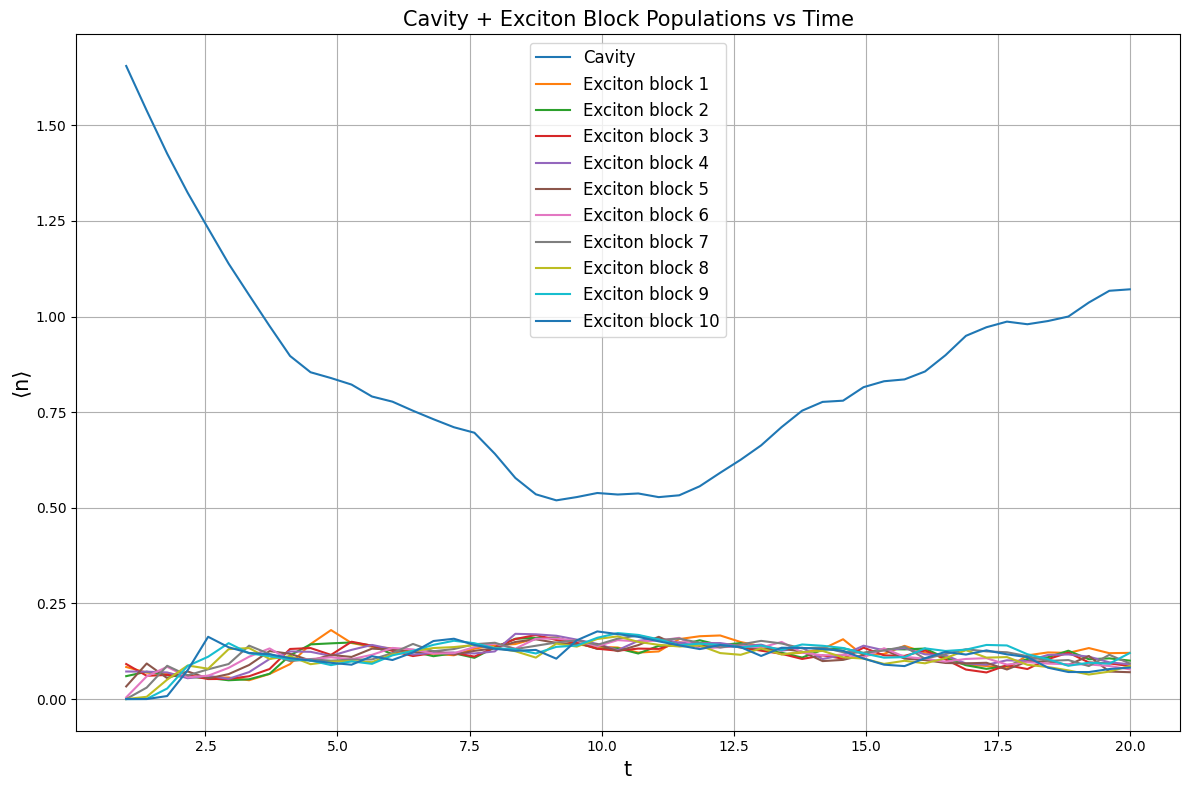

In [4]:
# -------------------------
# Parameters
# -------------------------

L = 49
num_particles = 2   # total excitations (cavity + excitons)
N_cav = 4           # maximum cavity occupancy allowed in basis
t_max = 20
num_samples = 50
times = np.linspace(1, t_max, num_samples)
# keep_exciton_sites = [L//2 + i for i in range(-2, 4)]  # exciton site indices to keep
block_size = 5
exciton_blocks = [
    list(range(i, min(i + block_size, L + 1)))
    for i in range(1, L + 1, block_size)
]
keep_exciton_sites = exciton_blocks[4]

# -------------------------
# Build Hamiltonian & basis
# -------------------------
H, basis = create_exciton_cavity_hamiltonian(
    L=L, t=9, U=4.5, t_nnn=3.5, U_nnn=2,
    g=1, omega_c=0.5, num_particles=num_particles, N_cav=N_cav
)

print(f"Basis dimension (constrained by num_particles={num_particles}): {len(basis)}")
print(f"Each basis tuple length (should be L+1 = {L+1}): {len(basis[0])}")
# for i in basis:
#     print(i)

# build index map once
index_map = {s: i for i, s in enumerate(basis)}

# -------------------------
# Initial state (cavity populated with 2, excitons ground)
# -------------------------
n_cavity_initial = 2

# basis tuple format used earlier: (n_cav, n_ex1, n_ex2, ..., n_exL)
initial_state = (n_cavity_initial,) + tuple(0 for _ in range(L))

# Sanity check: ensure proper tuple length
if len(initial_state) != L + 1:
    raise ValueError("target_state length mismatch: must be L+1 (cavity + L excitons)")

if initial_state not in index_map:
    raise RuntimeError(
        f"Requested initial state {initial_state} not present in basis. "
        "Check `num_particles` and `N_cav` (ensure N_cav >= n_cavity_initial and num_particles >= n_cavity_initial)."
    )

psi0 = np.zeros(len(basis), dtype=complex)
psi0[index_map[initial_state]] = 1.0            # So psi0 = (0,0,0,...,1)
print(f"idx for cav = {index_map[initial_state]}")

# -------------------------
# Diagonalize H and project
# -------------------------

evals, evecs = np.linalg.eigh(H)
proj_psi0 = evecs.T.conj() @ psi0

# -------------------------
# Find beta_star (thermal match)
# -------------------------
try:
    beta_star, E_init = find_beta_with_neg_temps_bosonic(H, psi0, bracket=(-100, 100))
except RuntimeError as exc:
    # Diagnostic: show thermal curve vs E_init to help choose bracket
    print("find_beta failed with RuntimeError:", exc)
    # attempt a wider bracket
    try:
        beta_star, E_init = find_beta_with_neg_temps_bosonic(H, psi0, bracket=(-1000, 1000))
    except RuntimeError:
        raise RuntimeError("Could not find beta_star in a wide bracket; inspect energy range or initial state.")

print(f"beta_star = {beta_star}, E_init = {E_init:.6f}")

# -------------------------
# Build thermal density (full) and reduced thermal on excitons kept
# -------------------------
weights = np.exp(-beta_star * evals)
weights /= np.sum(weights)
rho_thermal_full = (evecs * weights[np.newaxis, :]) @ evecs.conj().T
red_rho_thermal = reduced_density_matrix_with_cavity(rho_thermal_full, basis, keep_exciton_sites)

# -------------------------
# Useful helper to compute cavity photon number expectation for state vector psi (in full basis)
# -------------------------
def expectation_cavity_n(psi_state, basis):
    """⟨a†a⟩ for the cavity mode (first index of basis)."""
    probs = np.abs(psi_state)**2
    n_cav = np.array([state[0] for state in basis])
    return float(np.dot(probs, n_cav))

def expectation_exciton_blocks(psi_state, basis, exciton_blocks):
    """Compute ⟨Σ_{j in block} n_j⟩ for each block of excitons."""
    probs = np.abs(psi_state)**2
    n_block = np.zeros(len(exciton_blocks))
    for bi, block in enumerate(exciton_blocks):
        occ_sum = np.array([sum(state[j] for j in block) for state in basis])
        n_block[bi] = np.dot(probs, occ_sum)
    return n_block

def expectation_exciton_sum_on_kept(psi_state, basis, keep_exciton_sites):
    """Return sum of occupations on keep_exciton_sites for vector psi_state."""
    probs = np.abs(psi_state)**2
    occ_sums = np.array([sum(state[1 + s] for s in keep_exciton_sites) for state in basis])
    return float(np.dot(probs, occ_sums))

# -------------------------
# Observables per time
# -------------------------

def compute_observables(t):
    psi_t = evecs @ (np.exp(-1j * evals * t) * proj_psi0)
    rho_t = np.outer(psi_t, psi_t.conj())

    # --- reduced density for one exciton block (thermal comparison) ---
    red_rho_t = reduced_density_matrix_with_cavity(rho_t, basis, keep_exciton_sites)

    # --- distances between reduced states (for the chosen block only) ---
    D = trace_distance_calc(red_rho_t, red_rho_thermal)
    F = fidelity(red_rho_t, red_rho_thermal)
    S = relative_entropy(red_rho_t, red_rho_thermal)

    # --- population observables ---
    n_cav = expectation_cavity_n(psi_t, basis)
    n_blocks = expectation_exciton_blocks(psi_t, basis, exciton_blocks)

    return D, 1 - F, S, n_cav, n_blocks


# parallel execution over times
results = Parallel(n_jobs=-1)(delayed(compute_observables)(t) for t in times)
trace_distances, infidelities, rel_entropies, n_cav_list, n_blocks_list = map(list, zip(*results))
n_blocks_arr = np.array(n_blocks_list)  # shape = (num_times, num_blocks)

# -------------------------
# Plotting diagnostics
# -------------------------
plt.figure(figsize=(12, 8))
plt.plot(times, n_cav_list, label='Cavity')

for bi in range(len(exciton_blocks)):
    plt.plot(times, n_blocks_arr[:, bi], label=f'Exciton block {bi+1}')

plt.xlabel('t', fontsize=15)
plt.ylabel('⟨n⟩', fontsize=15)
plt.title('Cavity + Exciton Block Populations vs Time', fontsize=15)
plt.legend(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

# 1) This shows that my reduced thermal rho comes closed to thermal reduced rho.
# 2) The occupation of the three lattice sites becomes steady at long times. If I increase
# g/t (make cavity oscillations with exciton 1 stronger), then the occupations of those three
# excitons oscillate.